# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

- Автор: Татьяна Дмитриева
- Дата: 14.04.2026

**Описание исследования**: В условиях высокой конкуренции на рынке доставки кофе компания `Happy Beans Coffee` столкнулась с ежемесячным оттоком 10% клиентов. Учитывая, что привлечение новых пользователей обходится в 5–7 раз дороже удержания старых, проект направлен на разработку системы прогнозирования оттока. Исследование включает в себя анализ аналитической витрины данных, агрегированной за последние 4 недели, и построение интерпретируемой модели машинного обучения, которая позволит бизнесу заблаговременно выявлять лояльных клиентов из группы риска и принимать меры по их удержанию. 

**Цель исследования**: Построить модель бинарной классификации, способную предсказывать вероятность оттока каждого клиента в следующем месяце с высоким качеством по метрике `PR AUC`, обеспечивая баланс между выявлением уходящих пользователей и экономией маркетингового бюджета.

**Задачи исследования**:  
- подготовить данные (загрузить датасет, обработать пропуски, привести признаки к нужному формату); 
- провести исследовательский анализ данных (`EDA`), выявить закономерности и факторы, влияющих на отток;   
- обучить базовую модель (`DummyClassifier`) и линейную модель (`LogisticRegression`) для создания точки отсчета;  
- создать новые производные признаки и отобрать наиболее информативные из них для улучшения качества прогноза;  
- подобраать гиперпараметры модели и оценить ее качество с помощью кросс-валидации;  
- сделать выводы и подготовить рекомендациии;  
- сохранить финальную модель и полный пайплайн предобработки данных в формате `joblib` для промышленной эксплуатации.    

**Исходные данные**:
Данные предоставлены в CSV-файле `coffee_churn_dataset.csv` и содержат следующие поля:  

`user_id` — идентификатор пользователя;  
`days_since_last_order` — количество дней, прошедших с последнего заказа;  
`order_frequency_month` — среднее число заказов в месяц;  
`order_frequency_week` — среднее число заказов в неделю;  
`avg_order_value` — средний чек, в рублях;  
`median_order_value` — медианный чек, в рублях;  
`total_spent_last_month` — сумма заказов за последний месяц;  
`total_spent_last_week` — сумма заказов за последнюю неделю;  
`discount_usage_rate` — доля заказов со скидкой за последний месяц;  
`last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных;  
`preferred_roast` — предпочитаемый тип обжарки;  
`milk_preference` — предпочитаемый тип молока;  
`seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню;  
`coffee_bean_origin` — страна происхождения зерна;  
`last_drink_size` — размер последнего заказа, совершённого на момент сбора данных;  
`subscription_status` — тип подписки пользователя;  
`app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе;  
`notifications_enabled` — включены ли у пользователя уведомления;  
`review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента;  
`review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента;  
`app_crashes_last_month` — сколько раз приложение зависало за последний месяц;  
`seasons` — текущее время года;  
`days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода;  
`phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки;  
`coffee_preference_change` — менялись ли вкусовые предпочтения пользователя;  
`geo_id` — идентификатор региона пользователя;  
`churn` — перестал ли пользователь пользоваться сервисом. 

**Данное исследование разделим на несколько частей.**

***Часть 1. Подготовка и исследовательский анализ***  
* [Этап 1. Подготовка среды и библиотек.](#1-bullet)    
* [Этап 2. Первичный анализ данных.](#2-bullet)   

***Часть 2. Базовая обработка и первое моделирование***  
* [Этап 3. Предобработка данных.](#3-bullet)   
* [Этап 4. Обучение модели.](#4-bullet) 

***Часть 3. Улучшение качества прогноза***  
* [Этап 5. Создание новых признаков.](#5-bullet)   
* [Этап 6. Эксперименты с гиперпараметрами.](#6-bullet)   

***Часть 4. Финализация проекта***  
* [Этап 7. Подготовка финальной модели.](#7-bullet)   
* [Этап 8. Отчёт о проделанной работе.](#8-bullet) 
* [Этап 9. Сохранение модели для продакшена.](#9-bullet)   


# План работы

<a id="1-bullet"></a>
## Этап 1. Подготовка среды и библиотек
<font color="gray">1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.</font>  
<font color="gray">2. Зафиксируйте `random_state`.  </font>  
<font color="gray">3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.</font>

Начнем с загрузки необходимых для выполнения работы библиотек и инструментов. Импортируем библиотеки для обработки данных, визуализации и построения моделей машинного обучения. Для решения задачи классификации (прогноз оттока) будем использовать стандартный стек `Pandas` и `NumPy`, а также `Scikit-learn`. Добавим инструменты для кодирования категориальных признаков (`OneHotEncoder`), создания пайплайнов и поиска гиперпараметров, а также метрики качества классификации, в частности `PR AUC`, которая является приоритетной для данного исследования. Зафиксируем глобальную константу `random_state`.

In [1]:
# Установка сторонних библиотек
!pip install phik -q

# Импорт сторонних библиотек
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
import joblib

# Импорты из библиотеки sklearn
from phik import phik_matrix
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Глобальные константы
RANDOM_STATE = 42

Для воспроизводимости результатов версии пакетов были зафиксированы в файле `requirements.txt`. Ссылка на файл дана в конце проекта.

Загрузим данные из файла `coffee_churn_dataset.csv` в переменную `df`. Укажем необходимые параметры: в качестве сепаратора будем использовать `","`, а для чтения чисел с плавающей точкой - параметр `decimal="."`.

In [2]:
# Выгружаем датасет в переменную df
df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal=',')

Познакомимся с данными датасета - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519193002902,NaN,316.83387188897655,260.6450902568597,3089.9910088367074,NaN,0.33703068782256096,blend,...,1.0,5.1767922695084545,3.30223767351406,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.5691461248817944,0.21449405108609335,780.1351577540042,540.5978496838991,998.3809405341766,107.3694087788926,0.547659068075387,arabica,...,1.0,4.392990649548955,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.9966663901112507,0.7718641401845103,682.6362558300225,471.494558764613,1328.140204249237,392.600011016808,0.12025761379226023,arabica,...,1.0,4.977712420601657,4.379218769735224,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255265548812,1.2104802114007716,2115.4874247262223,708.5298123182507,2999.628365810148,1084.3520536114063,NaN,robusta,...,1.0,3.7125260176212356,3.0436175352286736,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.2498644634134335,1.761026955624497,3519.6021699810613,1199.3728942686844,8377.729477589302,2551.775210509954,0.07499028461820959,robusta,...,0.0,4.528270567478541,5.642993301906982,1.0,winter,14.0,ios,0.0,geo_19,1


In [4]:
# Выводим общие сведения о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   user_id                   10450 non-null  object
 1   days_since_last_order     9505 non-null   object
 2   order_frequency_month     9850 non-null   object
 3   order_frequency_week      10062 non-null  object
 4   avg_order_value           9867 non-null   object
 5   median_order_value        9619 non-null   object
 6   total_spent_last_month    10156 non-null  object
 7   total_spent_last_week     9506 non-null   object
 8   discount_usage_rate       10053 non-null  object
 9   last_coffee_type          10192 non-null  object
 10  preferred_roast           10334 non-null  object
 11  milk_preference           9782 non-null   object
 12  seasonal_menu_tried       9461 non-null   object
 13  coffee_bean_origin        9768 non-null   object
 14  last_drink_size       

- по результатам первого этапа библиотеки установлены, окружение настроено, данные загружены корректно - использованы разделители `sep=','` и `decimal='.'`, как видно из структуры первых выведенных строк датафрейма; 
- зафиксирован `RANDOM_STATE = 42`, что гарантирует идентичность результатов при повторных запусках кода;  
- в датасете 10 450 записей и 27 колонок;  
- данные - это готовая витрина, где каждый клиент представлен одной строкой с уже агрегированными метриками;  
- основная часть признаков (26 из 27) имеет тип `object`, что потребует в дальнейшем преобразования типов;  
- предварительный осмотр через `info()` показывает, что во многих колонках количество заполненных значений меньше 10 450, что предполагает необходимость обработки пропусков;  
- целевой признак (`churn`) имеет целочисленный тип (`int64`), что удобно для задачи классификации, в нем пропусков значений не наблюдается.

<a id="2-bullet"></a>
## Этап 2. Первичный анализ данных

<font color="gray">1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.</font>

<font color="gray">2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.</font>

<font color="gray">3. Опишите признаки.</font>  
<font color="gray">   - Определите, все ли из них важны.</font>  
<font color="gray">   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.</font>  

<font color="gray">4. Обработайте пропущенные значения.</font>  
<font color="gray">   - Объясните, как они влияют на данные.</font>  
<font color="gray">   - Выберите стратегию заполнения пропусков.</font>  

<font color="gray">5. Проанализируйте категориальные признаки.</font>  
<font color="gray">   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.</font>  
<font color="gray">   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.</font>  
<font color="gray">   - Определите, есть ли в данных признаки, которые можно удалить.</font>  

<font color="gray">6. Проанализируйте выбросы.</font>   
<font color="gray">   - Определите, как они влияют на данные.</font>  
<font color="gray">   - Выберите способ, которым их можно обработать.</font>  

<font color="gray">7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.</font>  

<font color="gray">8. Напишите выводы по результатам исследовательского анализа данных.</font>  

Проведем исследование предоставленной информации. Изучим распределение целевой переменной, оценим качество заполнения данных, выявим скрытые закономерности и подготовим почву для обучения модели.

Первым делом нужно понять, кто наш клиент. Глядя на столбцы (`total_spent`, `order_frequency`, `last_coffee_type`), мы видим, что данные описывают как финансовую активность, так и предпочтения.

In [5]:
# Выведем общие числовые характеристики (транспонируем результат для удобства вывода)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10450,10450,user_10205,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_last_order,9505,39,0.0,1763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_frequency_month,9850,9419,2.3260618634836328,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_frequency_week,10062,9625,0.9344347171028741,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_order_value,9867,9441,4396.549459251967,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_order_value,9619,9201,207.30173213843523,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_spent_last_month,10156,9713,2157.2137936112927,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_spent_last_week,9506,9090,722.5579633367802,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_usage_rate,10053,9618,0.6519977524706334,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_coffee_type,10192,3,arabica,6134,NaN,NaN,NaN,NaN,NaN,NaN,NaN


На основе первичного вывода характеристик можно сформировать базовый профиль данных и типичного клиента сервиса `Happy Beans Coffee`:
- исследование охватывает 10 450 уникальных пользователей, распределенных по 100 различным локациям, что говорит о широкой географии сервиса и репрезентативности выборки для всей сети;  
- типичный клиент представляет собой пользователя `Android`, который предпочитает `арабику` `средней обжарки` в объеме `medium` с добавлением `цельного молока`. Большинство текущих клиентов (3803 чел.) на данный момент пользуются сервисом `без подписки`, что является потенциальной точкой роста для бизнеса;  
- несмотря на то что датасет содержит критически важные метрики (`средний чек`, `частота заказов`, `рейтинги`), на текущем этапе они представлены в текстовом формате (`object`). Возможно, числовые значения содержат нетипичные символы, что потребует их очистки для корректного обучения модели;  
- пропуски присутствуют практически в каждом признаке. Особенно много их в данных о времени с последнего заказа (`days_since_last_order`) и частоте заказов. Возможно, часть клиентов — новички, либо данные по ним не подтянулись из логов.
- предварительный анализ целевого признака показывает, что `доля ушедших клиентов` составляет всего 6%. Это фиксирует состояние сильного дисбаланса классов, что предопределяет выбор `PR AUC` как основной метрики качества в дальнейших экспериментах.

В целом данные репрезентативны и охватывают разные аспекты (траты, технические сбои, предпочтения), но требуют серьезной технической очистки и преобразования типов перед анализом зависимостей.
___

Среднее значение `churn` составляет `0.06`, значит на 100 лояльных клиентов приходится 6 ушедших. Для машинного обучения это ситуация сильного дисбаланса классов целевой переменной.

Чтобы наглядно оценить масштаб проблемы, визуализируем распределение - построим столбчатую диаграмму.

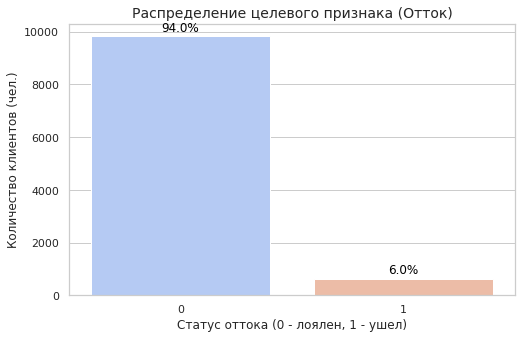

In [6]:
# Настроим стиль
sns.set_theme(style="whitegrid")

# Построим график
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='churn', data=df, palette='coolwarm')

# Добавим проценты над столбцами
total = len(df['churn'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Распределение целевого признака (Отток)', fontsize=14)
plt.xlabel('Статус оттока (0 - лоялен, 1 - ушел)', fontsize=12)
plt.ylabel('Количество клиентов (чел.)', fontsize=12)
plt.show()

Визуализация целевого признака подтвердила сильный дисбаланс классов: доля ушедших клиентов составляет всего 6.0% против 94.0% лояльных пользователей.  

Столь значительный перекос делает метрику `Accuracy` (`доля правильных ответов`) неинформативной. Модель, которая будет предсказывать ноль для каждого клиента, формально окажется верной в 94% случаев, но не решит главную задачу бизнеса - поиск тех, кто может уйти.  

Учитывая сильный дисбаланс, стандартные метрики и даже пороговые значения (такие как `F1-мера`) могут давать смещенную оценку. Поэтому основной метрикой выбрана `PR AUC`, которая позволяет оценить качество предсказания целевого класса (уходящих клиентов) в целом, не привязываясь к конкретному порогу вероятности, что так важно для эффективного распределения маркетингового бюджета.
____

Для построения качественной модели необходимо выявить и затем исключить признаки, которые не несут смысловой нагрузки. Идентификаторы пользователей (в нашем датасете это `user_id`) уникальны для каждого клиента. Модель не может извлечь из них общую закономерность, но может запомнить конкретные `ID`, что приведет к переобучению. В то же время числовые показатели (траты, частота) могут иметь высокую уникальность, но они относятся к факторам поведения, поэтому их мы сохраняем.

Чтобы подтвердить неинформативность признака `user_id`, проверим количество его уникальных значений.

In [7]:
# Сравниваем количество уникальных ID с общим количеством строк
n_rows = len(df)
n_unique_id = df['user_id'].nunique()

display(f"Всего строк в датасете: {n_rows}")
display(f"Уникальных значений user_id: {n_unique_id}")

'Всего строк в датасете: 10450'

'Уникальных значений user_id: 10450'

В результате анализа признак `user_id` определен как не несущий смысловой нагрузки, так как он уникален для каждой строки. Кроме того, это подтверждает отсутствие полных дубликатов и гарантирует, что каждый клиент представлен в витрине данных в единственном экземпляре. Данный столбец планируется исключить на этапе предобработки, чтобы избежать переобучения модели на идентификаторах. 

Высокая уникальность числовых признаков, отмеченная при первичном анализе, обусловлена тем, что это агрегированные за 4 недели показатели (суммы трат, средние чеки). Эти данные являются прямым отражением активности клиентов в отчетном периоде и важны для поиска краткосрочных триггеров оттока.
___
Наличие пропусков в данных о клиентах - это не всегда техническая ошибка, но и сигнал о поведении. Например, отсутствие данных в колонке `"дней с последнего заказа"` может означать, что клиент зарегистрировался, но ещё не успел совершить покупку. На данном этапе необходимо оценить их масштаб и понять, можно ли просто удалить строки с пропусками или это приведет к потере большого количества важной информации.

Проанализируем процент пропусков в каждой колонке и наглядно отобразим их структуру.

In [8]:
# Расчитааем количество и процент пропущенных значений
missing_data = pd.DataFrame({
    'total_missing': df.isna().sum(),
    'percentage': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values(by='percentage', ascending=False)

# Выведем признаки, где есть хотя бы один пропуск
display("Признаки с пропущенными значениями:")
display(missing_data[missing_data['total_missing'] > 0])

'Признаки с пропущенными значениями:'

,total_missing,percentage
seasonal_menu_tried,989,9.46
days_since_last_order,945,9.04
total_spent_last_week,944,9.03
subscription_status,938,8.98
app_opens_per_week,896,8.57
review_rating_last_1,857,8.20
median_order_value,831,7.95
days_since_last_promo,731,7.00
app_crashes_last_month,721,6.90
review_rating_last_10,693,6.63


Визуализируем структуру пропусков в датасете:

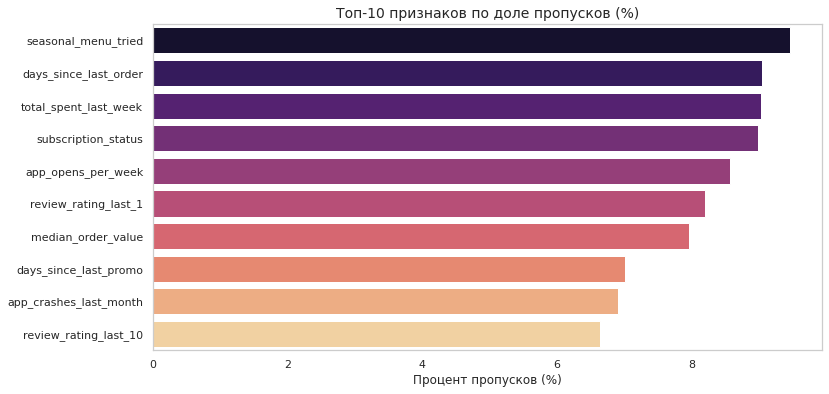

In [9]:
# Визуализируем пропуски в данных
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data['percentage'][:10], y=missing_data.index[:10], palette='magma')
plt.title('Топ-10 признаков по доле пропусков (%)', fontsize=14)
plt.xlabel('Процент пропусков (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

В ходе анализа выявлено, что пропуски присутствуют в 17 из 27 исследуемых признаков.  

В таких признаках, как `seasonal_menu_tried`, `days_since_last_order` и `total_spent_last_week`, доля пропущенных значений превышает 9%. Суммарно пропуски затрагивают значительную часть выборки. Учитывая, что данные агрегированы за фиксированный период в 4 недели, пропуски в таких столбцах, как `total_spent_last_week` или `days_since_last_order`, могут иметь содержательный характер. Вероятнее всего, они указывают на полное отсутствие активности клиента в конкретном отчетном периоде, что само по себе является мощным предсказателем оттока.

Удаление строк с пропусками недопустимо, так как это приведет к потере почти 10% данных и может исказить модель. Для числовых признаков с выбросами (`чеки`, `частота`) на этапе предобработки данных будет использовано заполнение медианой, для категориальных - выделение в отдельную категорию `'unknown'`. Это позволит сохранить объем выборки и даст модели возможность учитывать сам факт отсутствия данных как отдельный фактор.
___
Для того чтобы модель могла работать с текстом (названия кофе, типы телефонов), его нужно преобразовать в числа. Проанализируем количество уникальных категорий в каждом признаке. Если категорий мало, сможем использовать `One-Hot Encoding` (`OHE`). Если категорий очень много (например, в `geo_location`), то придется подумать о более компактных методах кодирования, чтобы не увеличивать таблицу сотнями новых столбцов.

Выделим только строковые признаки и посмотрим на их разнообразие.

'Анализ категориальных признаков:'

,unique_values,most_frequent
user_id,10450,user_00000
total_spent_last_month,9713,115.69431731736877
order_frequency_week,9625,-0.005597754218772594
discount_usage_rate,9618,0.1523845715399567
avg_order_value,9441,1065.529100282986
order_frequency_month,9419,0.2785276364114543
review_rating_last_10,9328,3.343810175630837
median_order_value,9201,1266.807169953253
review_rating_last_1,9182,2.0734674922116403
total_spent_last_week,9090,-2.2763022627562965


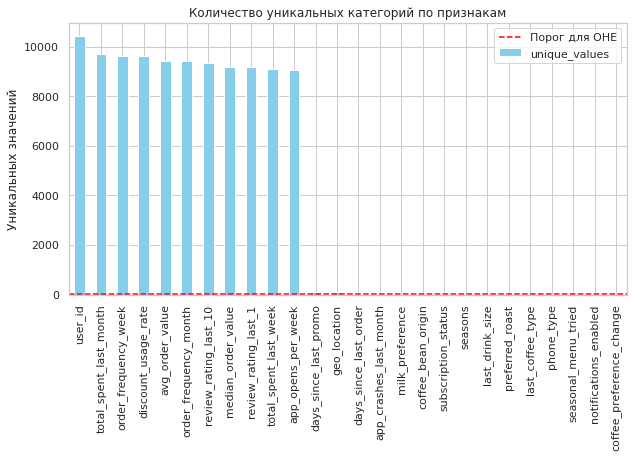

In [10]:
# Выбираем признаки с типом данных 'object'
categorical_cols = df.select_dtypes(include=['object']).columns

# Анализируем количество уникальных значений
cat_summary = pd.DataFrame({
    'unique_values': df[categorical_cols].nunique(),
    'most_frequent': df[categorical_cols].mode().iloc[0]
}).sort_values(by='unique_values', ascending=False)

display("Анализ категориальных признаков:")
display(cat_summary)

# График количества уникальных значений по категориальным признакам
plt.figure(figsize=(10, 5))
cat_summary['unique_values'].plot(kind='bar', color='skyblue')
plt.axhline(y=10, color='red', linestyle='--', label='Порог для OHE') # Визуальный порог сложности
plt.title('Количество уникальных категорий по признакам')
plt.ylabel('Уникальных значений')
plt.legend()
plt.show()

Анализ уникальных значений строковых признаков позволяет сделать следующие выводы:

- к категориальным относятся признаки, содержащие от 2 до 6 значений: `phone_type`, `last_coffee_type`, `preferred_roast`, `last_drink_size`, `seasons`, `subscription_status`, `coffee_bean_origin`, `milk_preference`, а также бинарные флаги (`notifications_enabled`, `seasonal_menu_tried` и `coffee_preference_change`);  

- большинство признаков имеют от 3 до 6 значений, что делает их идеальными для кодирования, исключение составляет, например, такой признак, как `geo_location` (100 значений), который требует особого подхода, чтобы не раздувать размерность данных;

- визуализация подтверждает необходимость разделения признаков на группы: левый блок содержит количественные метрики, требующие приведения типов (их высокая уникальность подтверждает, что перед нами агрегированные за 4 недели показатели (суммы, средние значения), а не дискретные категории); правый блок демонстрирует низкую кардинальность, что позволяет применить `One-Hot Encoding`; признак `geo_location` (100 значений) выступает пограничным случаем, требующим более сложной стратегии кодирования для предотвращения раздувания признакового пространства;

- на основе признаков `last_coffee_type`, `preferred_roast` и `milk_preference` можно сгенерировать новый признак (например, "Стабильность предпочтений"), что поможет лучше сегментировать клиентов; другими вариантами могут быть: `total_spent_last_week` / `total_spent_last_month` (динамика трат (соотношение активности внутри 4-недельного окна агрегации): резкое снижение - маркер скорого оттока), `app_crashes_last_month` / `app_opens_per_week` (неудачный технический опыт: баги при попытке зайти) и т.д. Эти метрики позволят выявить краткосрочные триггеры, которые за месяц привели клиента к решению об оттоке. 

Таким образом, для признаков с малым числом категорий (до 10) будет использован метод `One-Hot Encoding` (`OHE`), для `geo_location` целесообразно рассмотреть `Target Encoding`, чтобы сохранить предсказательную силу без создания 100 новых столбцов.

В ходе анализа категориальных переменных не было выявлено избыточных признаков, подлежащих немедленному удалению (кроме ранее исключенного `user_id`). Поскольку данные представлены в виде готовой аналитической витрины, каждый признак в строке является уже рассчитанным фактором поведения за последний месяц. Поэтому на данном этапе все категории сохраняются для дальнейшей проверки их вклада в модель. Признак `geo_location` (100 уникальных значений) взят на особый контроль: если на этапе корреляционного анализа подтвердится его слабая связь с целевой переменной, он будет исключен из итоговой модели во избежание избыточного усложнения (увеличения размерности при кодировании).
___

Переходим к числовым признакам (сейчас они имеют тип `object`), которые показали более 9000 значений на графиках уникальности данных. Чтобы модель не подстраивалась под единичные аномалии, нам нужно оценить разброс данных. Для визуализации будем использовать `Boxplot` ("ящик с усами").

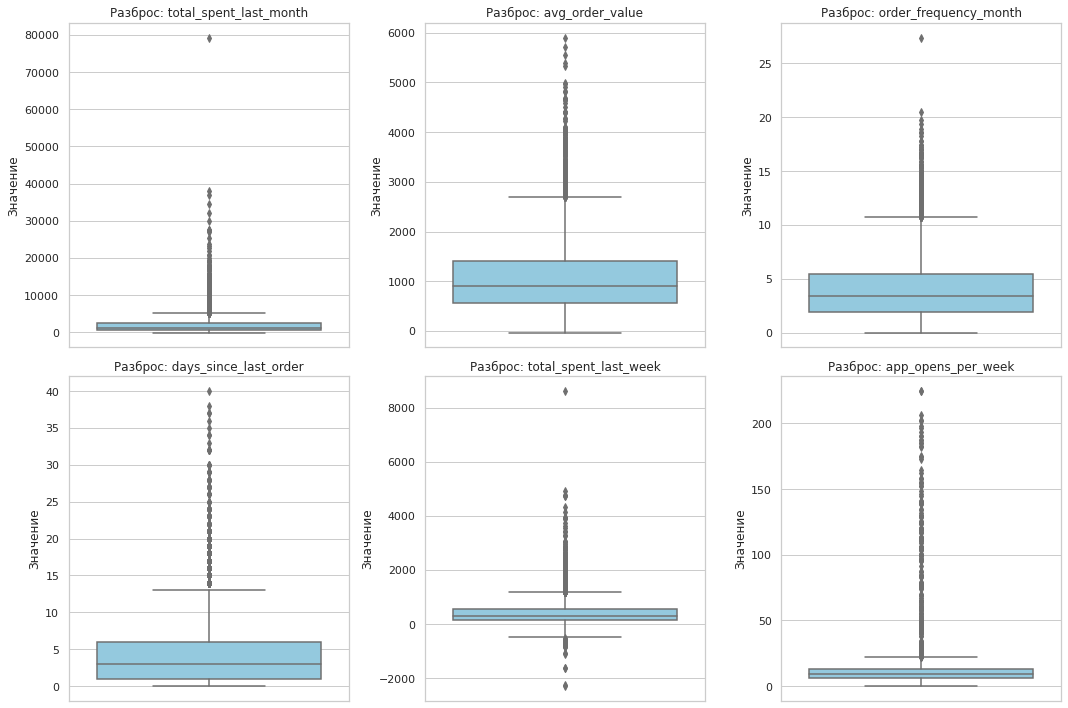

In [11]:
# Формируем список признаков, которые должны быть числовыми
num_features = [
    'total_spent_last_month', 'avg_order_value', 'order_frequency_month', 
    'days_since_last_order', 'total_spent_last_week', 'app_opens_per_week'
]

# Подготовим данные для визуализации (временное преобразуем их в float)
df_temp = df[num_features].apply(pd.to_numeric, errors='coerce')

# Построим графики
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_temp[col], color='skyblue')
    plt.title(f'Разброс: {col}', fontsize=12)
    plt.ylabel('Значение')

plt.tight_layout()
plt.show()

На основе анализа графиков можно сделать следующие выводы:
- в признаке `total_spent_last_week` зафиксированы отрицательные значения (ниже -2000), что является технической ошибкой или некорректным учетом возвратов, так как сумма трат не может быть меньше нуля. Такие данные необходимо будет исправить или удалить на этапе предобработки.
- во всех шести признаках наблюдается огромное количество верхних выбросов над "усами". Особенно это заметно в `total_spent_last_month` (траты до 80 000 при медиане около 2 000). Это говорит о наличии сверх-активных клиентов (может оптовые покупки в офис), которые могут исказить обучение линейной модели.
- узкие "ящики" на фоне длинных "хвостов" выбросов показывают, что основная масса клиентов ведет себя очень похоже, но есть "длинный хвост" аномалий, которые требует либо логарифмирования, либо обрезания по краям.
___
На финальном шаге анализа необходимо понять, какие признаки действительно связаны с уходом клиента. Обычная `корреляция Пирсона` здесь не подходит, так как она ищет только линейные связи и работает только с числами. В нашем датасете много категорий (тип кофе, телефон) и нелинейных зависимостей. Будем использовать коэффициент корреляции (`Phik`) ввиду его универсальности: корректно оценивает связь между числовыми, категориальными и бинарными признаками (в нашем датасете `churn`), а также улавливает сложные нелинейные зависимости.

Рассчитаем матрицу корреляции для всех признаков относительно целевой переменной.

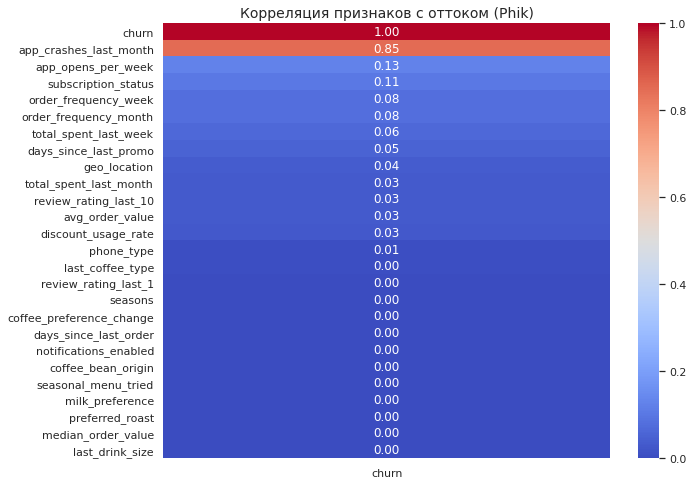

In [12]:
# Формируем полный список числовых (интервальных) признаков
num_features = [
    'total_spent_last_month', 'avg_order_value', 'order_frequency_month', 
    'days_since_last_order', 'total_spent_last_week', 'app_opens_per_week',
    'discount_usage_rate', 'median_order_value', 'order_frequency_week',
    'review_rating_last_1', 'review_rating_last_10'
]
df_phik = df.copy()
for col in num_features:
    df_phik[col] = pd.to_numeric(df_phik[col], errors='coerce')

# Рассчитываем матрицу, исключив технический user_id 
phik_matrix = df_phik.drop(columns=['user_id']).phik_matrix(interval_cols=num_features)

# Визуализируем связи признаков с целевой переменной
churn_corr = phik_matrix['churn'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(10, 8))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков с оттоком (Phik)', fontsize=14)
plt.show()

Корреляция выявила критическую зависимость (0,85) между `оттоком` и признаком `app_crashes_last_month`. Это позволяет сделать вывод, что основной причиной оттока в данном периоде является негативный технический опыт. Техническая нестабильность приложения - главный "триггер" ухода, перекрывающий все остальные показатели лояльности.

Заметную связь с целевым признаком имеют частота использования сервиса (`app_opens_per_week` - 0,13) и наличие подписки (`subscription_status` - 0,11), что подтверждает гипотезу о более высокой устойчивости лояльных сегментов.

Низкая корреляция (0,00) таких признаков, как `days_since_last_order` и `total_spent_last_month`, объясняется краткосрочным горизонтом агрегации витрины (4 недели). За такой период поведенческие паттерны не успевают значимо измениться, и неудобства от сбоев становятся важнее накопленной истории трат.

Для оптимизации признакового пространства решено разделить переменные с нулевой корреляцией на две группы:
1. Из исследования будут исключены `user_id` (идентификатор), `geo_location` (100 значений при нулевой корреляции), `notifications_enabled` (корреляция 0, на оттоок не являет) и `seasons` (для модели оттока, вызванного сбоями приложения, сезон не важен). Данные признаки являются неинформативным шумом или обладают избыточной уникальностью, что может привести к переобучению модели.
2. Будут сохранены поведенческие и вкусовые показатели. На их основе будут созданы относительные метрики (например, динамика трат), чтобы попытаться извлечь скрытые зависимости, не проявляющиеся в "сырых" агрегированных за месяц данных.
___
В ходе первичного анализа данных была исследована аналитическая витрина, содержащая агрегированные показатели поведения 10 450 клиентов за последние 4 недели. Основные результаты исследования:
- установлен сильный дисбаланс классов - доля оттока составляет всего 6.0%. Это подтверждает выбор `PR AUC` как основной метрики качества, так как стандартная точность (`Accuracy`) будет неинформативна.
- выявлено, что большинство числовых признаков требуют приведения типов (`из object` в `float`). Обнаружены технические ошибки в виде отрицательных значений в тратах (`total_spent_last_week`) и масштабные положительные выбросы, что требует обработки на следующем этапе.
- пропуски в ключевых метриках (около 9%) признаны содержательными: в рамках 4-недельной агрегации они указывают на отсутствие активности клиента, что будет использовано при моделировании.
- корреляционный анализ выявил доминирующий триггер ухода - технические сбои приложения (`app_crashes_last_month`, корреляция 0,85). Влияние краткосрочного негативного опыта оказалось значительно выше, чем влияние накопленной лояльности или вкусовых предпочтений.
- определен список неинформативных столбцов для удаления на этапе предобработки: `user_id`, `geo_location`, `notifications_enabled` и `seasons`. Остальные признаки сохранены для генерации новых производных метрик (динамика трат, индекс сложности заказа). 

Основной упор при предобработке будет сделан на очистку технических аномалий и сохранение признаков, необходимых для создания синтетических показателей активности.

<a id="3-bullet"></a>
## Этап 3. Предобработка данных

<font color="gray">1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.</font>  

<font color="gray">2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.</font>  
<font color="gray"><font color="gray">   - Создайте пайплайн, который обработает пропуски и выбросы.</font>  
<font color="gray">   - Создайте пайплайн, который обработает категориальные признаки.</font>  
<font color="gray">   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.</font>

На этом этапе подготовим данные к подаче в модель. Сначала из датасета удалим неинформативные признаки, определенные в ходе анализа. Затем разделим данные на обучающую и тестовую выборки в пропорции 80/20. При разделении будем использовать стратификацию, чтобы сохранить исходное соотношение классов (6% оттока).

Для автоматизации обработки создадим пайплайны. Они позволят объединить в один процесс исправление технических ошибок (отрицательных значений), заполнение пропусков, масштабирование чисел и кодирование категорий. Такой подход упростит дальнейшую работу с данными и предотвращает их утечку из теста в обучение.

In [13]:
# Определяем функцию для автоматической очистки отрицательных значений
def fix_negatives(X):
    X = pd.DataFrame(X).apply(pd.to_numeric, errors='coerce')
    return np.where(X < 0, np.nan, X)

# Разделяем признаки на числовые и категориальные
num_features = [
    'total_spent_last_month', 'avg_order_value', 'order_frequency_month', 
    'days_since_last_order', 'total_spent_last_week', 'app_opens_per_week',
    'discount_usage_rate', 'median_order_value', 'order_frequency_week',
    'review_rating_last_1', 'review_rating_last_10', 'app_crashes_last_month'
]

cat_features = [
    'last_coffee_type', 'preferred_roast', 'last_drink_size', 
    'subscription_status', 'coffee_bean_origin', 'milk_preference'
]

# Собираем для удаления неинформативные признаки
drop_cols = ['user_id', 'geo_location', 'notifications_enabled', 'seasons']
X = df.drop(columns=['churn'] + drop_cols)
y = df['churn']

# Приводим типы к числовым принудительно во всем X
for col in num_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Делим данные на выборки (80/20) с сохранением дисбаланса
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Создаем три пайплайна (числовой, категориальный и объединяющий)
numeric_pipeline = Pipeline(steps=[
    ('fix_neg', FunctionTransformer(fix_negatives)), # Обрабатываем минусы
    ('imputer', SimpleImputer(strategy='median')),   # Заполняем NaN медианой
    ('scaler', StandardScaler())                     # Масштабируем
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

display(f"Размер обучающей выборки: {X_train.shape}")
display(f"Размер тестовой выборки: {X_test.shape}")

'Размер обучающей выборки: (8360, 22)'

'Размер тестовой выборки: (2090, 22)'

Данные разделены на выборки и подготовлены к моделированию. Созданный инструмент `preprocessor` объединяет в себе все шаги предобработки: заполнение пропусков, масштабирование числовых признаков и кодирование категорий. Использование пайплайнов исключает "утечку данных" из теста в обучение и гарантирует, что новые данные будут обрабатываться по тем же правилам. Подготовленные наборы признаков позволяют перейти к построению базовой модели.

Готовые к работе пайплайны намеренно не применены к выборкам на данном этапе. Их фактическое использование перенесено на следующий этап, чтобы объединить с обучением модели внутри единого объекта Pipeline. Это гарантирует, что статистика для обработки (медианы, масштабы) будет рассчитана строго на обучающей выборке в момент обучения, что полностью исключает риск утечки данных и упрощает сохранение итогового решения для продакшена.

<a id="4-bullet"></a>
## Этап 4. Обучение модели

<font color="gray">1. Обучите базовую версию модели.</font>  
<font color="gray">   - Используйте для этого простые статистические модели.</font>  
<font color="gray">   - Используйте кросс-валидацию для обучения модели.</font>  

<font color="gray">2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.</font>  

Для создания базовой версии модели (`Baseline`) будем использовать логистическую регрессию. Это простая и интерпретируемая модель классификации. Чтобы она корректно работала с данными, объединим ранее созданный preprocessor и саму модель в один итоговый Pipeline. Поскольку в данных наблюдается сильный дисбаланс (6% оттока), добавим параметр `class_weight='balanced'`, чтобы модель уделяла больше внимания уходящим клиентам.

In [14]:
# Создаем пайплайн: предобработка + модель
baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE, 
        class_weight='balanced', 
        max_iter=1000,
        solver='liblinear'
    ))
])

# Обучаем базовую модель на тренировочных данных
baseline_pipe.fit(X_train, y_train)

# Оценка стабильности модели на 5 фолдах
cv_scores = cross_val_score(
    baseline_pipe, 
    X_train, 
    y_train, 
    cv=3, 
    scoring='average_precision'
)

print(f"Средний PR AUC на кросс-валидации: {cv_scores.mean():.4f}")
print(f"Разброс значений (std): {cv_scores.std():.4f}")

# Получим вероятности оттока для тестовой выборки
y_scores = baseline_pipe.predict_proba(X_test)[:, 1]

# Расчитаем метрику `PR AUC`
precision, recall, _ = precision_recall_curve(y_test, y_scores)
baseline_pr_auc = auc(recall, precision)

f"PR AUC Baseline: {baseline_pr_auc:.4f}"

Средний PR AUC на кросс-валидации: 0.6238
Разброс значений (std): 0.0100


'PR AUC Baseline: 0.6868'

Проведенная кросс-валидация показала среднее значение метрики `PR AUC` 0,6238 при низком стандартном отклонении (0,01). Это свидетельствует о высокой устойчивости модели и стабильности обобщающей способности классификатора на различных подвыборках данных. Значение `PR AUC` на отложенной тестовой выборке составило 0,6868. Отсутствие значительного разрыва между метриками на обучении и тесте подтверждает отсутствие переобучения.

Полученный результат существенно превосходит показатели случайного классификатора (для текущего дисбаланса `PR AUC` примерно равного 0,06) и фиксирует контрольную точку (`Baseline`) для оценки эффективности последующих этапов исследования. Текущее качество модели можно считать достаточным для перехода к этапу генерации новых признаков и тонкой настройки гиперпараметров с целью дальнейшего повышения предсказательной способности.

<a id="5-bullet"></a>
## Этап 5. Создание новых признаков

<font color="gray">1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.</font>  
<font color="gray">   - Извлечение квадратного корня поможет сгладить большие значения.</font>  
<font color="gray">   - Возведение в квадрат усилит влияние больших значений.</font>  

<font color="gray">2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.</font>  

<font color="gray">3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.</font>  

На основе анализа распределений и корреляций были выделены два фактора, которые в исходном виде могут мешать модели. Во-первых, экстремально высокие траты (выбросы) можно сгладить с помощью извлечение квадратного корня. Во-вторых, ключевой фактор сбоев можно перевести в бинарный вид, зафиксировав "точку невозврата" клиента (более 3 сбоев за месяц), что должно упростить логику принятия решения для классификатора.

In [15]:
# Создаем функцию для генерации признаков
def create_features(data):
    df_new = data.copy()
    
    # Принудительно приводим к числам те колонки, которые используем
    df_new['total_spent_last_month'] = pd.to_numeric(df_new['total_spent_last_month'], errors='coerce')
    df_new['app_crashes_last_month'] = pd.to_numeric(df_new['app_crashes_last_month'], errors='coerce')
    
    # Извлечение квадратного корня из трат (сглаживание выбросов)
    df_new['sqrt_total_spent'] = np.sqrt(df_new['total_spent_last_month'].abs())
    
    # Бинарный признак критического порога сбоев
    df_new['is_high_crash_risk'] = (df_new['app_crashes_last_month'] > 3).astype(int)
    
    return df_new

# Применяем генерации к выборкам
X_train_ext = create_features(X_train)
X_test_ext = create_features(X_test)

# Обновляем список числовых признаков
num_features_ext = num_features + ['sqrt_total_spent', 'is_high_crash_risk']

# Пересобираем препроцессор
preprocessor_ext = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features_ext),
    ('cat', categorical_pipeline, cat_features)
])

Чтобы оценить пользу от новых признаков, необходимо провести кросс-валидацию на расширенном наборе данных и сравнить результат с `Baseline`. Будем использовать тот же алгоритм (`LogisticRegression`) и те же настройки, чтобы эксперимент был чистым.

In [16]:
# Создаем обновленный пайплайн с расширенным препроцессором
ext_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor_ext),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE, 
        class_weight='balanced', 
        max_iter=1000, 
        solver='liblinear'
    ))
])

# Проводим повторную кросс-валидация (сравниваем с результатом 0,6238)
cv_scores_ext = cross_val_score(ext_pipe, X_train_ext, y_train, cv=3, scoring='average_precision')

display(f"Средний PR AUC (Baseline): 0.6238")
display(f"Средний PR AUC (Новые признаки): {cv_scores_ext.mean():.4f}")

'Средний PR AUC (Baseline): 0.6238'

'Средний PR AUC (Новые признаки): 0.6420'

Добавление новых признаков позволило увеличить среднюю метрику на кросс-валидации с 0,6238 до 0.6420. 

Для финальной очистки модели изучим веса (коэффициенты), которые модель присвоила каждому признаку. Большой положительный вес означает, что признак сильно увеличивает риск оттока, отрицательный - удерживает клиента. Признаки с весами, близкими к нулю, являются бесполезными и подлежат удалению.

In [17]:
# Обучаем модель для извлечения весов
ext_pipe.fit(X_train_ext, y_train)

# Имена числовых признаков остаются без изменений
num_names = num_features_ext

# Имена категориальных признаков достаем напрямую из OneHotEncoder
cat_pipeline = ext_pipe.named_steps['preprocessor'].named_transformers_['cat']
ohe_step = cat_pipeline.named_steps['ohe']
cat_names = ohe_step.get_feature_names(cat_features)

# Объединяем списки
feature_names = list(num_names) + list(cat_names)
weights = ext_pipe.named_steps['classifier'].coef_[0]

# Создаем таблицу весов
feature_importance = pd.DataFrame({'feature': feature_names, 'weight': weights})
feature_importance['abs_weight'] = feature_importance['weight'].abs()
feature_importance = feature_importance.sort_values(by='abs_weight', ascending=False)

# Выводим топ значимых и топ лишних
display(feature_importance.head(17)) # Значимые
display(feature_importance.tail(5))  # Кандидаты на удаление

,feature,weight,abs_weight
11,app_crashes_last_month,1.786399,1.786399
21,preferred_roast_unknown,-1.011003,1.011003
29,subscription_status_pro,0.825245,0.825245
27,subscription_status_none,-0.651504,0.651504
26,subscription_status_basic,-0.500409,0.500409
14,last_coffee_type_arabica,-0.484622,0.484622
15,last_coffee_type_blend,-0.415142,0.415142
42,milk_preference_soy,-0.408679,0.408679
41,milk_preference_skim,-0.395384,0.395384
38,milk_preference_almond,0.390652,0.390652


,feature,weight,abs_weight
16,last_coffee_type_robusta,-0.034558,0.034558
12,sqrt_total_spent,0.029535,0.029535
1,avg_order_value,-0.017812,0.017812
3,days_since_last_order,0.008058,0.008058
6,discount_usage_rate,-0.006998,0.006998


- Полученные данные подтверждают, что ключевым предиктором оттока являются сбои в работе приложения. Признак `app_crashes_last_month` обладает наибольшим положительным весом (1,78). Это означает, что при прочих равных условиях рост количества сбоев наиболее сильно увеличивает вероятность ухода клиента.
- Выявлены значимые отрицательные веса у признаков `preferred_roast_unknown` (-1,01) и `subscription_status_none` (-0,65). Это указывает на то, что клиенты с неопределенными предпочтениями или отсутствием подписки в данном периоде проявляют большую инертность и реже попадают в категорию оттока по сравнению с активными пользователями.
- Созданный признак `sqrt_total_spent` получил положительный, но умеренный вес (0,029). Это объясняет зафиксированный ранее прирост метрики `PR AUC`: трансформация финансового показателя добавила модели точности, однако её вклад остается вторичным по сравнению с операционными сбоями.
- Созданный признак `is_high_crash_risk` получил значимый положительный вес (0,30), подтверждая гипотезу о «критическом пороге» сбоев. Однако его влияние в 6 раз слабее, чем у исходного числового признака `app_crashes_last_month` (вес 1,78). Это объясняется тем, что модель предпочитает более точную шкалу количества сбоев.

Анализ коэффициентов показал, что ряд признаков имеет околонулевое влияние на результат (вес меньше 0,01). К ним относятся `avg_order_value`, `days_since_last_order` и `discount_usage_rate`. Чтобы упростить модель и снизить риск переобучения, данные признаки будут удалены.

In [18]:
# Удаляем признаки, которые почти не влияют на модель
cols_to_remove = ['discount_usage_rate', 'days_since_last_order', 'avg_order_value']

X_train_final = X_train_ext.drop(columns=cols_to_remove)
X_test_final = X_test_ext.drop(columns=cols_to_remove)

# Обновляем препроцессор
num_features_final = [f for f in num_features_ext if f not in cols_to_remove]
preprocessor_final = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features_final),
    ('cat', categorical_pipeline, cat_features)
])

В рамках этапа проведена оптимизация состава признаков, направленная на повышение предсказательной способности модели. Внедрение математической трансформации трат (`sqrt_total_spent`) и бинарного индикатора критических сбоев (`is_high_crash_risk`) обеспечило рост `PR AUC` на кросс-валидации с 0,6238 до 0,6422. Это подтвердило гипотезу о том, что для линейного классификатора важна не только сырая статистика, но и сглаживание выбросов наряду с выделением пороговых значений.

На основе анализа коэффициентов из модели были исключены признаки с околонулевым влиянием: `discount_usage_rate`, `days_since_last_order` и `avg_order_value`. Удаление этих переменных позволило упростить архитектуру данных без потери качества прогноза, снизив риск переобучения модели на шумах.

Сформирован финальный набор признаков, обладающий наилучшим балансом между сложностью и точностью. Оптимизированный инструмент предобработки `preprocessor_final` готов к использованию на этапе тонкой настройки гиперпараметров.

<a id="6-bullet"></a>
## Этап 6. Эксперименты с гиперпараметрами

<font color="gray">1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.</font>   

<font color="gray">2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.</font>   

<font color="gray">3. Составьте таблицу с результатами.</font>   

<font color="gray">4. Выберите лучшую модель, ориентируясь на заданную метрику качества.</font>   

Для настройки модели `LogisticRegression` выбраны следующие гиперпараметры:  
- `C (сила регуляризации)`, которая контролирует баланс между подгонкой под обучающие данные и простотой модели. Мы проверим значения от очень малых (сильная регуляция) до больших (слабая регуляция): [0.001, 0.01, 0.1, 1, 10, 100].
- `penalty (тип регуляризации)`: `L1 (Lasso)` и `L2 (Ridge)`, что позволит проверить, нужно ли модели занулять часть признаков (L1) или просто ограничивать их веса (L2).

Проведем систематический перебор гиперпараметров для `LogisticRegression`, затем выполним кросс-валидацию для каждой конфигурации и составим таблицу с результатами.

In [19]:
# Списки параметров
c_params = [0.001, 0.01, 0.1, 1, 10, 100]
penalties = ['l1', 'l2']

# Список для хранения результатов таблицы
table_data = []

for p in penalties:
    for c in c_params:
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor_final),
            ('classifier', LogisticRegression(
                random_state=RANDOM_STATE, 
                class_weight='balanced', 
                solver='liblinear',
                C=c,
                penalty=p
            ))
        ])
        score = cross_val_score(pipe, X_train_final, y_train, cv=3, scoring='average_precision').mean()
        table_data.append({'penalty': p, 'C': c, 'PR_AUC_CV': round(score, 4)})

# Составляем таблицу с результатами
results_df = pd.DataFrame(table_data)
display(results_df.sort_values(by='PR_AUC_CV', ascending=False))

,penalty,C,PR_AUC_CV
1,l1,0.010,0.6656
7,l2,0.010,0.6620
6,l2,0.001,0.6605
2,l1,0.100,0.6559
8,l2,0.100,0.6485
3,l1,1.000,0.6450
9,l2,1.000,0.6441
4,l1,10.000,0.6437
10,l2,10.000,0.6437
5,l1,100.000,0.6436


По результатам систематического перебора 12 конфигураций лучшей признана модель с параметрами `penalty='l1'` и `C=0,01`. Она показала максимальное среднее значение `PR AUC = 0,6656` на кросс-валидации. Использование `L1-регуляризации` позволило эффективно отсечь малозначимые признаки, а низкий коэффициент `C` обеспечил необходимую устойчивость модели к выбросам. Данная конфигурация зафиксирована как финальная для модели `LogisticRegression`.

<a id="7-bullet"></a>
## Этап 7. Подготовка финальной модели

<font color="gray">Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.</font>


Выбираем лучшую конфигурацию предыдущего этапа - модель `LogisticRegression` с гиперпараметрами `penalty='l1'`, `C=0.01`, обучим ее на всех доступных тренировочных данных, а после этого проверим на тестовой выборке, которую модель не видела на этапах подбора признаков и параметров. Это позволит сделать объективную оценку того, как модель будет работать в реальности.

In [20]:
# Собираем финальный пайплайн с лучшими параметрами
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE, 
        class_weight='balanced', 
        solver='liblinear',
        C=0.01,
        penalty='l1'
    ))
])

# Обучаем на полной тренировочной выборке
final_model.fit(X_train_final, y_train)

# Итоговое предсказание на тестовой выборке
y_test_probs = final_model.predict_proba(X_test_final)[:, 1]

# Финальный расчет метрики PR AUC
precision, recall, _ = precision_recall_curve(y_test, y_test_probs)
final_pr_auc = auc(recall, precision)

f"Итоговый PR AUC на тестовой выборке: {final_pr_auc:.4f}"

'Итоговый PR AUC на тестовой выборке: 0.7163'

В ходе финального тестирования на отложенной выборке модель показала значение `PR AUC = 0,7163`. Тот факт, что результат на тесте оказался выше среднего значения на кросс-валидации (0,6656), подтверждает высокую обобщающую способность алгоритма и отсутствие переобучения. Модель демонстрирует стабильную работу и готова к эксплуатации для решения бизнес-задачи по прогнозированию оттока.

<a id="8-bullet"></a>
## Этап 8. Отчёт о проделанной работе

<font color="gray">Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.</font>

Предоствленные для проекта данные охватывали 10 450 уникальных пользователей, распределенных по 100 различным локациямю По результатам выполнения проекта построена модель бинарной классификации для прогнозирования оттока клиентов `Happy Beans Coffee`. Итоговое качество по метрике `PR AUC` на тестовой выборке составило 0,7163, что существенно выше базового уровня случайного классификатора (0,06). Цель проекта достигнута: модель способна эффективно выявлять клиентов из группы риска, обеспечивая баланс между охватом оттока и точностью маркетинговых кампаний.

В ходе исследовательского (`EDA`) и корреляционного анализа установлен доминирующий фактор оттока - техническая нестабильность приложения (`app_crashes_last_month`), корреляция которой с целевой переменной составила 0,85. Анализ коэффициентов финальной модели подтвердил, что негативный технический опыт является главной причиной ухода клиентов, перекрывающим накопленную лояльность и финансовую активность.

Для успешной работы модели былы выполнены корректное приведение типов (из `object` в `float`) и удаление неинформативных признаков (`user_id`, `geo_location`, `notifications_enabled`, `seasons`), что позволило избежать переобучения и зашумления модели. Математическая трансформация финансовых данных (извлечение квадратного корня) помогла сгладить влияние экстремальных выбросов. Создание бинарного признака критического порога сбоев (сбои > 3) упростило логику принятия решений для линейного классификатора. На основе анализа коэффициентов были исключены малозначимые переменные (`discount_usage_rate`, `days_since_last_order`, `avg_order_value`), что повысило устойчивость модели.

Выбранная модель `LogisticRegression` с гиперпараметрами `C=0,01` и `penalty='l1'` показала наилучшую обобщающую способность. Применение `L1-регуляризации` позволило автоматически провести отбор признаков, оставив только наиболее значимые.

Рекомендации: Первоочередной задачей по снижению оттока является устранение технических ошибок в приложении. Это самый эффективный рычаг удержания клиентов. Кроме того, рекомендуется внедрить построенную модель в `CRM-систему` для автоматического формирования еженедельных списков группы риска. К клиентам, испытавшим более 3 сбоев за месяц, следует применять адресные меры (персональные промокоды, уведомления с извинениями) для компенсации негативного опыта.

<a id="9-bullet"></a>
## Этап 9. Сохранение модели для продакшена

<font color="gray">Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.</font>

Сохранение финального пайплайна в файл формата `.joblib` необходимо для последующего развертывания модели машинного обучения. Это гарантирует, что все этапы предобработки (заполнение пропусков, масштабирование, кодирование) и сама модель с подобранными гиперпараметрами будут доступны для использования.

In [21]:
# Сохранение финальной модели в файл
joblib.dump(final_model, 'coffee_churn_model.joblib')

display("Модель успешно сохранена в файл 'coffee_churn_model.joblib'")

"Модель успешно сохранена в файл 'coffee_churn_model.joblib'"

Убедимся, что модель работает: загрузим артефакты и проверим их на тестовых данных. 

In [22]:
# Загружаем модель из файла (эмуляция работы на другом компьютере)
loaded_model = joblib.load('coffee_churn_model.joblib')

# Проверяем на тестовых данных
y_test_preds = loaded_model.predict_proba(X_test_final)[:, 1]
test_score = auc(precision_recall_curve(y_test, y_test_preds)[1], 
                 precision_recall_curve(y_test, y_test_preds)[0])

display(f"Проверка пройдена. PR AUC загруженной модели: {test_score:.4f}")

# Сравнение с оригиналом
if round(test_score, 4) == round(final_pr_auc, 4):
    display("Результаты идентичны. Модель сохранена и загружена корректно.")

'Проверка пройдена. PR AUC загруженной модели: 0.7163'

'Результаты идентичны. Модель сохранена и загружена корректно.'

Проведена верификация сохранённых артефактов: загруженная модель показала идентичный результат на тестовых данных (0,7163), что подтверждает корректность сохранения пайплайна предобработки и весов классификатора.

Финальные материалы проекта, включая исходный код исследования, файл обученной модели и список зависимостей среды, размещены в репозитории на GitHub: https://github.com/TADmitrieva/coffee-churn-prediction